In [35]:
import json
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
%config InlineBackend.figure_formats = ['svg']
mpl.rcParams.update({
    'text.usetex' : True,
    'font.size' : 14,
    'font.family' : "sans-serif",
    'font.sans-serif' : 'Helvetica',
    'font.serif' : 'Palatino'
})
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from itertools import product

def plot_matrix(
    matrix,
    value_labels,
    xvals,
    yvals,
    ax=None,
    legend_title="Categories",
    show_legend=True,
    show_values=False,
    cmap='cvidis'
):
    """
    Plots a matrix with integer values, mapping each unique value to a specific color
    from an inbuilt Matplotlib colormap and displaying a legend with custom labels.

    Args:
        matrix (np.ndarray): A 2D NumPy array of integer values.
        value_labels (dict): A dictionary mapping unique integer values to their
                             descriptive string labels (e.g., {0: "Empty", 1: "Object A"}).
        cmap_name (str, optional): The name of an inbuilt Matplotlib colormap to use.
                                   Defaults to 'cividis'.
    """
    unique_values = np.unique(matrix)
    num_unique_values = len(unique_values)

    # Validate that all unique values have a defined label
    if not all(val in value_labels for val in unique_values):
        missing_labels = [val for val in unique_values if val not in value_labels]
        raise ValueError(f"Missing labels for unique values: {missing_labels}")

    if len(yvals) != matrix.shape[0]:
        raise ValueError(f"yvals has {len(yvals)} entries but matrix has {matrix.shape[0]} columns.")
    
    if len(xvals) != matrix.shape[1]:
        raise ValueError(f"xvals has {len(xvals)} entries but matrix has {matrix.shape[1]} columns.")

    # Get the inbuilt colormap
    base_cmap = plt.get_cmap(cmap)

    # Create a ListedColormap by sampling colors from the base_cmap
    colors = [base_cmap(i / (num_unique_values - 1)) for i in range(num_unique_values)]
    cmap = mcolors.ListedColormap(colors)

    # Create a normalizer that maps the actual values to the range [0, len(unique_values)-1]
    # BoundaryNorm is suitable for discrete values.
    # The bounds define the edges of the bins. For N colors, you need N+1 bounds.
    # We create bounds such that each unique value falls into its own bin.
    # Sort unique_values to ensure correct mapping with bounds
    sorted_unique_values = np.sort(unique_values)
    bounds = np.append(sorted_unique_values, sorted_unique_values[-1] + 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N) # cmap.N is the number of colors in the colormap

    if ax is None:
        fig, ax = plt.subplots()
        
    # Plot the matrix using imshow with the custom colormap and normalization
    im = ax.imshow(matrix, cmap=cmap, norm=norm, interpolation='nearest')

    # Optional: Add text labels on top of each cell
    if show_values:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, str(matrix[i, j]), ha='center', va='center', color='black', fontsize=10)

    # Create custom legend handles and labels
    legend_handles = []
    legend_labels = []

    # Map unique values to their corresponding colors from the *sampled* colormap
    # The colors are indexed by their position in the sorted unique_values list
    value_to_color_map = {val: cmap(i) for i, val in enumerate(sorted_unique_values)}

    for val in sorted_unique_values:
        color = value_to_color_map[val]
        label = value_labels[val]
        patch = mpatches.Patch(color=color, label=label)
        legend_handles.append(patch)
        legend_labels.append(label)

    # Add the ticks to the plot
    ax.set_xticks(range(len(xvals)),labels=xvals)
    ax.set_yticks(range(len(yvals)), labels=yvals)
    ax.set_xticks(np.arange(len(xvals)-1) + 0.5, minor=True)
    ax.set_yticks(np.arange(len(xvals)-1) + 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

    # Add the legend to the plot
    if show_legend:
        ax.legend(
            handles=legend_handles,
            title=legend_title,
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            borderaxespad=0
        )
    
    return ax

def confusion_matrix(v, w):
    v_vals = np.unique(v)
    w_vals = np.unique(w)
    res = np.zeros((len(v_vals), len(w_vals)))
    for i in v_vals:
        t = (np.array(v) == i)
        for j in w_vals:
            res[i, j] = np.logical_and(t, np.array(w) == j).sum()
    return res


In [2]:
results_dir = Path("../results").resolve()

results_df_list = []
for (k, pca, filename_modifier) in [
    (3, False, ""), 
    (4, False, "k4_"), 
    (3, True, "pca_"), 
    (4, True, "k4_pca_")
]:
    with results_dir.joinpath(
        f"eee_prediction_{filename_modifier}results.json"
    ).open("r") as f:
        results = json.load(f)
        result_df = pd.DataFrame(results["results"])
        result_df["k"] = [k] * result_df.shape[0]
        result_df["pca"] = [pca] * result_df.shape[0]
        results_df_list.append(result_df)

results_df = pd.concat(results_df_list, ignore_index=True)
results_df["label"] = results_df["label"].astype("category")
labels_map = dict(enumerate(results_df["label"].cat.categories))
results_df["label"] = results_df["label"].cat.codes
# labels_map
results_df

,c_half,chi_c^m,label,predicted_class,purity,k,pca
0,0.1,3.5,0,1,1.000000,3,False
1,0.2,3.5,0,1,1.000000,3,False
2,0.3,3.5,0,1,0.700000,3,False
3,0.1,4.0,0,1,1.000000,3,False
4,0.2,4.0,0,1,1.000000,3,False
...,...,...,...,...,...,...,...
319,0.6,2.5,2,0,1.000000,4,True
320,0.7,2.5,2,0,1.000000,4,True
321,0.8,2.5,2,0,1.000000,4,True
322,0.9,2.5,2,0,1.000000,4,True


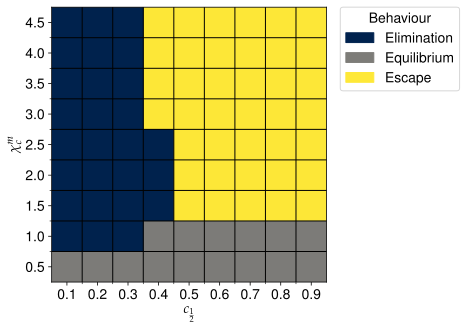

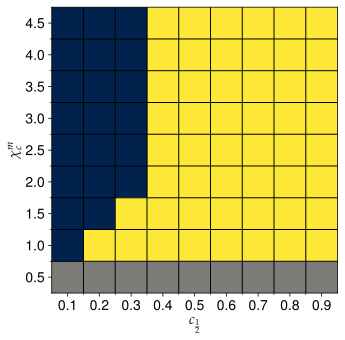

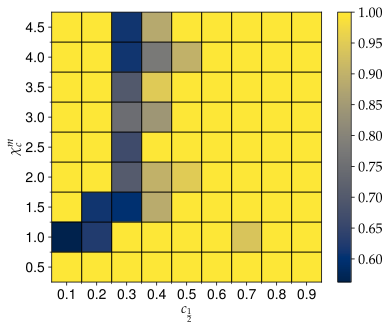

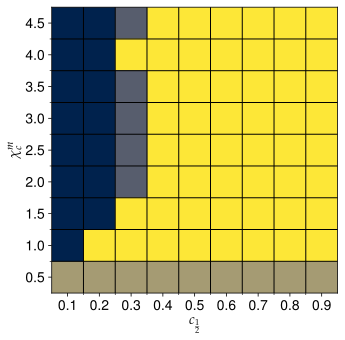

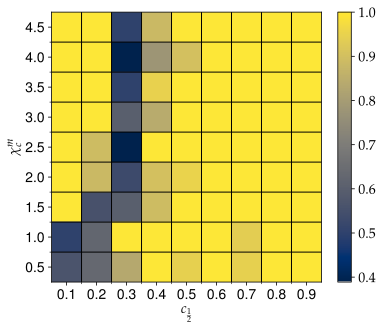

In [39]:
# Subjective classification labels
label_df = (
    results_df.loc[results_df["k"] == 3, ["c_half", "chi_c^m", "label"]]
    .pivot_table(index="chi_c^m", columns = "c_half", values="label", observed=False)
    )
label_arr = label_df.astype(int).to_numpy()[::-1, :]
# Parameter values for the axes ticks
chi_cm = label_df.index.to_numpy()[::-1]
c_half = label_df.columns
# Plot the subjective classification
fig, ax = plt.subplots()
plot_matrix(
    label_arr,
    labels_map,
    xvals=c_half,
    yvals=chi_cm,
    ax=ax,
    cmap="cividis",
    legend_title="Behaviour"
)
# ax.set_title("Subjective classification")
ax.set_xlabel(r"$c_{\frac{1}{2}}$", family="serif", size=14, weight="bold")
ax.set_ylabel(r"$\chi_c^m$", family="serif", size=14, weight="bold")
fig.tight_layout()
fig.savefig(results_dir.joinpath("figures/subjective_labels.pdf"), bbox_inches="tight", pad_inches=0)
fig.savefig(results_dir.joinpath("figures/subjective_labels.svg"), bbox_inches="tight", pad_inches=0)

classification_df_list = []
purity_df_list = []
for (k, pca) in product([3, 4], [False]):
    temp = results_df.loc[(results_df["k"] == k) & (results_df["pca"] == pca)].copy()
    # Align the labels so that we get the right colours
    cm = confusion_matrix(temp["label"], temp["predicted_class"])
    if k == len(labels_map):
        cm_argmax = cm.argmax(axis=0)
        temp["predicted_class_aligned"] = np.array([cm_argmax[i] for i in temp["predicted_class"]])
        legend_labels = labels_map
    elif k==4:
        labels_align_map = {}
        cm_sort_row, cm_sort_col = np.unravel_index(np.argsort(cm, axis=None), cm.shape)
        for i, j in zip(cm_sort_row[::-1], cm_sort_col[::-1]):
            if j in labels_align_map.keys() or i in labels_align_map.values():
                continue
            labels_align_map[j] = i
        legend_labels = { val : labels_map[val] for val in labels_align_map.values() }
        for i, j in enumerate(set(temp["predicted_class"]).difference(labels_align_map.keys())):
            labels_align_map[j] = 0.5
            legend_labels[0.5] = "Quasi-stable region"
        temp["predicted_class_aligned"] = np.array([
            labels_align_map[i]
            for i in temp["predicted_class"]
        ])
    # Create a matrix of labels
    classification_df = (
        temp[["c_half", "chi_c^m", "predicted_class_aligned"]]
        .pivot_table(index="chi_c^m", columns = "c_half", values="predicted_class_aligned", observed=False)
    )
    classification_arr = classification_df.to_numpy()[::-1, :]
    
    # Plot the classification labels
    fig, ax = plt.subplots(figsize=(5,5))
    plot_matrix(
        classification_arr,
        legend_labels,
        xvals=c_half,
        yvals=chi_cm,
        ax=ax,
        cmap="cividis",
        legend_title="Behaviour",
        show_legend=False,
    )
    # ax.set_title(f"Predicted labels (k={k}, pca={pca})")
    ax.set_xlabel(r"$c_{\frac{1}{2}}$", family="serif", size=14, weight="bold")
    ax.set_ylabel(r"$\chi_c^m$", family="serif", weight="bold",size=14)
    fig.tight_layout()
    fig.savefig(results_dir.joinpath(f"figures/predicted_labels_k={k}_pca={pca}.pdf"), bbox_inches="tight", pad_inches=0)
    fig.savefig(results_dir.joinpath(f"figures/predicted_labels_k={k}_pca={pca}.svg"), bbox_inches="tight", pad_inches=0)
    # Get the purity matrix of the classification
    purity_df = (
        temp[["c_half", "chi_c^m", "purity"]]
        .pivot_table(index="chi_c^m", columns = "c_half", values="purity", observed=False)
    )
    purity_arr = purity_df.to_numpy()[::-1, :]
    
    # Plot the purity matrix
    fig, ax = plt.subplots()
    t = ax.imshow(purity_arr, cmap='cividis')
    fig.colorbar(t, ax=ax, fraction=0.046, pad=0.04)
    # Add the ticks to the plot
    ax.set_xticks(range(len(c_half)),labels=c_half)
    ax.set_yticks(range(len(chi_cm)), labels=chi_cm)
    ax.set_xticks(np.arange(len(c_half)-1) + 0.5, minor=True)
    ax.set_yticks(np.arange(len(chi_cm)-1) + 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    # ax.set_title(f"Classification purity (k={k}, pca={pca})")
    ax.set_xlabel(r"$c_{\frac{1}{2}}$", family="serif", size=14, weight="bold")
    ax.set_ylabel(r"$\chi_c^m$", family="serif", size=14, weight="bold")
    fig.tight_layout()
    fig.savefig(results_dir.joinpath(f"figures/purity_k={k}_pca={pca}.pdf"), bbox_inches="tight", pad_inches=0)
    fig.savefig(results_dir.joinpath(f"figures/purity_k={k}_pca={pca}.svg"), bbox_inches="tight", pad_inches=0)